In [1]:
#Let’s import the libraries we’ll be using.

import numpy as np
import scipy
import pandas
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('white')
sns.set_style('ticks')
sns.set_context('notebook')
import h5py
import allel
import zarr
import matplotlib.patches as patches  # <-- This is the missing import
import pickle
import pandas as pd

In [20]:
chrom_regions='/home/usriniva/Desktop/masters/plasmodium/find_regions_recomb/regions.txt'
chrom_regions= pd.read_csv(chrom_regions, sep='\t',names=['chrom', 'start', 'end', 'region_type'])
chrom_regions.tail()

,chrom,start,end,region_type
105,Pf3D7_14_v3,35775,1071523,Core
106,Pf3D7_14_v3,1071524,1075089,Centromere
107,Pf3D7_14_v3,1075090,3255710,Core
108,Pf3D7_14_v3,3255711,3291511,SubtelomericHypervariable
109,Pf3D7_14_v3,3291512,3291936,SubtelomericRepeat


In [21]:
# Calculate total length of each chromosome
chrom_lengths = chrom_regions.groupby('chrom')['end'].max()

# Convert chrom_lengths (Series) to DataFrame
chrom_lengths = pd.DataFrame(chrom_lengths)

# Display total chromosome lengths
print(chrom_lengths)

                 end
chrom               
Pf3D7_01_v3   640851
Pf3D7_02_v3   947102
Pf3D7_03_v3  1067971
Pf3D7_04_v3  1200490
Pf3D7_05_v3  1343577
Pf3D7_06_v3  1418242
Pf3D7_07_v3  1445207
Pf3D7_08_v3  1472805
Pf3D7_09_v3  1541735
Pf3D7_10_v3  1687656
Pf3D7_11_v3  2038340
Pf3D7_12_v3  2271494
Pf3D7_13_v3  2925236
Pf3D7_14_v3  3291936


In [22]:
tbl_co = '/home/usriniva/Desktop/masters/plasmodium/find_regions_recomb/tbl_co.txt'
tbl_co= pd.read_csv(tbl_co, sep='\t')
tbl_co_chr14 = tbl_co[tbl_co['chrom'].str.contains('Pf3D7_14_v3')]
tbl_co_chr14_pos=tbl_co_chr14['co_pos_mid']
allel.windowed_count(tbl_co_chr14_pos, size=10000, start=1, stop=3291936, step=5000)

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 2, 2, 0, 0, 1,
        1, 1, 3, 4, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
        0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 1, 1, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 2, 2,
        0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 0, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 1, 2, 2, 2, 1, 0, 0, 0, 1, 3, 2, 0, 2, 2,
        0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        1, 0, 0, 2, 3, 4, 3, 0, 0, 0, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 1, 2,
        2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
        0, 1, 1, 0, 0, 0, 0, 3, 3, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 2, 2,
        1, 1, 0, 0, 1, 1, 0, 0, 2, 2, 

In [3]:
vcf_file_path_full = '/home/usriniva/Desktop/masters/NASmountpoint/Plasmodium_us/Inputs/VCFs/vcf_gz/vcg.gz.r3/vcfs_w_newmissfilt_newpops/Nofilt/Pf3D7_Nofilt_qcpass_White_combined.vcf.gz'
zarr_full = '/home/usriniva/Desktop/masters/zarrs/AllChr_qcpass_Nofilt_White_combined.zarr'
allel.vcf_to_zarr(vcf_file_path_full, zarr_full, group='All_chr', fields='*', transformers=allel.ANNTransformer(),overwrite=True)



In [5]:
zarr_full = '/home/usriniva/Desktop/masters/zarrs/AllChr_qcpass_Nofilt_White_combined.zarr'
callset_full = zarr.open_group(zarr_full, mode='r')



In [7]:
# Load the right table
samples_p = '/home/usriniva/Desktop/masters/plasmodium/VCFs/2_Samplemd_files/Final_Dataset_bydapcclusters_remoutliers/Allchr_Whitefullfilt_Newdapc_bycluster_md.txt'
samples_right = pd.read_csv(samples_p, sep='\t')
print('No of Individuals (right table):', len(samples_right))

# Add 'subpops' information based on 'assgn_clus'
samples_right['subpops'] = 'NA'  # Default value for unmatched samples
samples_right.loc[samples_right['assgn_clus'] == 1, 'subpops'] = 'MaeSot_Thailand'
samples_right.loc[samples_right['assgn_clus'] == 6, 'subpops'] = 'PurPai_Cambodia'
samples_right.loc[samples_right['assgn_clus'] == 4, 'subpops'] = 'BinhPhuoc_Long_Vietnam'

# Load the left table
samples_o_p = '/home/usriniva/Desktop/masters/plasmodium/VCFs/2_Samplemd_files/Total_dataset_TRACwhite2011/White_1052_ctv_471inds_depthfilt_samplemd.txt'
samples_left = pd.read_csv(samples_o_p, sep='\t')
print('No of Individuals (left table):', len(samples_left))

# Merge the tables using a left join: match 'Sample' from the left table with 'Individuals' from the right
merged = samples_left.merge(samples_right[['Individual', 'subpops']], how='left', left_on='Sample', right_on='Individual')

# Verify the data type of 'assgn_clus'
print(f"Data type of 'subpops': {merged['subpops'].dtype}")

# Check if 'assgn_clus' contains only the values 1, 4, 6
print(merged['subpops'].value_counts())
# Define subpopulations based on 'subpops' column in the merged DataFrame
subpops = {
    'all': list(range(len(merged))),  # All individuals in the merged dataset
    'MaeSot_Thailand': merged[merged['subpops'] == "MaeSot_Thailand"].index.tolist(),
    'PurPai_Cambodia': merged[merged['subpops'] == "PurPai_Cambodia"].index.tolist(),
    'BinhPhuoc_Long_Vietnam': merged[merged['subpops'] == "BinhPhuoc_Long_Vietnam"].index.tolist()
}


No of Individuals (right table): 270
No of Individuals (left table): 448
Data type of 'subpops': str
subpops
BinhPhuoc_Long_Vietnam    156
MaeSot_Thailand            89
PurPai_Cambodia            25
Name: count, dtype: int64


In [8]:
gt_zarr = callset_full['All_chr/calldata/GT']
gt_zarr.info
gt = allel.HaplotypeArray(callset_full['All_chr/calldata/GT'][:,:,0])
gt
genotypes_full = allel.HaplotypeChunkedArray(gt)
print(len(genotypes_full))

variants_full = allel.VariantChunkedTable(callset_full['All_chr/variants'], 
                                     names=['POS', 'CHROM', 'numalt', 'REF', 'ALT', 'DP', 'MQ', 'QD','ANN_Annotation'])
gt_full = allel.HaplotypeArray(callset_full['All_chr/calldata/GT'][:,:,0])
print(gt.shape)
genotypes_full = allel.HaplotypeChunkedArray(gt_full)


482115
(482115, 471)


In [9]:
# Create an ArrayWrapper object from the variants.CHROM array
chrom_uniq = np.unique(variants_full['CHROM'])
chrom_uniq

array(['Pf3D7_01_v3', 'Pf3D7_02_v3', 'Pf3D7_03_v3', 'Pf3D7_04_v3',
       'Pf3D7_05_v3', 'Pf3D7_06_v3', 'Pf3D7_07_v3', 'Pf3D7_08_v3',
       'Pf3D7_09_v3', 'Pf3D7_10_v3', 'Pf3D7_11_v3', 'Pf3D7_12_v3',
       'Pf3D7_13_v3', 'Pf3D7_14_v3'], dtype=object)

In [11]:
variants_full['CHROM'][:]

array(['Pf3D7_01_v3', 'Pf3D7_01_v3', 'Pf3D7_01_v3', ..., 'Pf3D7_14_v3',
       'Pf3D7_14_v3', 'Pf3D7_14_v3'], shape=(482115,), dtype=object)

In [12]:
regions='/home/usriniva/Desktop/masters/plasmodium/find_regions_recomb/regions.txt'

regions= pd.read_csv(regions, sep='\t', names=['region_chrom', 'region_start', 'region_stop', 'region_type'])

regions_non_accessible = regions[
    (regions['region_type'] == 'SubtelomericRepeat') |
    (regions['region_type'] == 'SubtelomericHypervariable') |
    (regions['region_type'] == 'InternalHypervariable')
]

regions_non_accessible.head()

,region_chrom,region_start,region_stop,region_type
0,Pf3D7_01_v3,1,27336,SubtelomericRepeat
1,Pf3D7_01_v3,27337,92900,SubtelomericHypervariable
5,Pf3D7_01_v3,575901,616691,SubtelomericHypervariable
6,Pf3D7_01_v3,616692,640851,SubtelomericRepeat
7,Pf3D7_02_v3,1,23100,SubtelomericRepeat


In [13]:
chrom_variants = {}
assessibility_mask = []

# Initialize a dictionary to store chromosomal variants and accessibility mask
chrom_variants = {}
assessibility_mask = {}

for chrom in chrom_uniq:
    # Create a boolean mask for the current chromosome
    mask_chrom = variants_full['CHROM'] == chrom
    
    # Use compress to subset the variants for the current chromosome
    chrom_variants[chrom] = variants_full.compress(mask_chrom)
    
    # Subset regions that correspond to the current chromosome
    regions_non_accessible_chrom = regions_non_accessible[regions_non_accessible['region_chrom'] == chrom]
    
    # Extract the positions of the variants
    POS = chrom_variants[chrom]['POS'][:]
    
    # Create an empty mask (True means accessible, False means non-accessible)
    chrom_mask = np.ones(len(POS), dtype=bool)
    
    # Iterate through each region in the non-accessible regions for the current chromosome
    for _, region in regions_non_accessible_chrom.iterrows():
        print(f"Region: {region}")  # Debugging line to print the region
        region_start = region['region_start']
        region_stop = region['region_stop']
        
        # Check if any POS is within the current region range
        # Mark positions that lie between region_start and region_stop as False (non-accessible)
        mask = (POS >= region_start) & (POS <= region_stop)
        
        # Print positions that are being marked as non-accessible (optional)
        print(f"Marking {sum(mask)} positions as non-accessible in region {region_start}-{region_stop}")
        
        # Set the chrom_mask to False for all positions within the range
        chrom_mask[mask] = False
        
    # Store the mask for the current chromosome in the dictionary
    assessibility_mask[chrom] = chrom_mask

# Check if any positions are marked as non-accessible for any chromosome
for chrom, mask in assessibility_mask.items():
    if np.any(mask == False):
        print(f"Chromosome {chrom} has non-accessible positions.")
    else:
        print(f"Chromosome {chrom} has all positions accessible.")

Region: region_chrom           Pf3D7_01_v3
region_start                     1
region_stop                  27336
region_type     SubtelomericRepeat
Name: 0, dtype: object
Marking 0 positions as non-accessible in region 1-27336
Region: region_chrom                  Pf3D7_01_v3
region_start                        27337
region_stop                         92900
region_type     SubtelomericHypervariable
Name: 1, dtype: object
Marking 0 positions as non-accessible in region 27337-92900
Region: region_chrom                  Pf3D7_01_v3
region_start                       575901
region_stop                        616691
region_type     SubtelomericHypervariable
Name: 5, dtype: object
Marking 0 positions as non-accessible in region 575901-616691
Region: region_chrom           Pf3D7_01_v3
region_start                616692
region_stop                 640851
region_type     SubtelomericRepeat
Name: 6, dtype: object
Marking 0 positions as non-accessible in region 616692-640851
Region: region_chrom

In [14]:
chrom='Pf3D7_01_v3'
# Create a boolean mask for the current chromosome
mask_chrom = variants_full['CHROM'] == chrom
    
# Use compress to subset the variants for the current chromosome
chrom_variants[chrom] = variants_full.compress(mask_chrom)
regions_non_accessible_chrom = regions_non_accessible[regions_non_accessible['region_chrom'] == 'Pf3D7_01_v3']
print(regions_non_accessible_chrom)
POS= chrom_variants['Pf3D7_01_v3']['POS'][:]
print(POS) 
# Create an empty mask (True means accessible, False means non-accessible)
chrom_mask = np.ones(chrom_variants['Pf3D7_01_v3'].shape[0], dtype=bool)

len(chrom_mask)


  region_chrom  region_start  region_stop                region_type
0  Pf3D7_01_v3             1        27336         SubtelomericRepeat
1  Pf3D7_01_v3         27337        92900  SubtelomericHypervariable
5  Pf3D7_01_v3        575901       616691  SubtelomericHypervariable
6  Pf3D7_01_v3        616692       640851         SubtelomericRepeat
[ 92914  92918  92935 ... 575279 575284 575895]


9911

In [17]:
regions_non_accessible_chrom

,region_chrom,region_start,region_stop,region_type
0,Pf3D7_01_v3,1,27336,SubtelomericRepeat
1,Pf3D7_01_v3,27337,92900,SubtelomericHypervariable
5,Pf3D7_01_v3,575901,616691,SubtelomericHypervariable
6,Pf3D7_01_v3,616692,640851,SubtelomericRepeat


In [180]:
np.any(chrom_mask == False)

False

In [155]:
chrom_variants['Pf3D7_01_v3']['POS'][:]

array([ 92914,  92918,  92935, ..., 575279, 575284, 575895], dtype=int32)

In [23]:
# Calculate total length of each chromosome
chrom_lengths = chrom_regions.groupby('chrom')['end'].max()

# Convert chrom_lengths (Series) to DataFrame
chrom_lengths = pd.DataFrame(chrom_lengths).reset_index()

# Rename columns if necessary
chrom_lengths.columns = ['chrom', 'end']

In [24]:
# Initialize a dictionary to store chromosomal variants and accessibility mask
chrom_variants = {}
assessibility_mask = {}

for chrom in chrom_uniq:
    # Subset regions that correspond to the current chromosome
    regions_non_accessible_chrom = regions_non_accessible[regions_non_accessible['region_chrom'] == chrom]
    
    # Get the length of the chromosome (chrom_lengths is a DataFrame)
    chrom_length_for_mask = chrom_lengths[chrom_lengths['chrom'] == chrom]['end'].values[0]  # Get the value as integer
    
    # Create an empty mask (True means accessible, False means non-accessible)
    chrom_mask = np.ones(chrom_length_for_mask, dtype=bool)

    # Iterate through each region in the non-accessible regions for the current chromosome
    for _, region in regions_non_accessible_chrom.iterrows():
        print(f"Region: {region}")  # Debugging line to print the region
        region_start = region['region_start']
        region_stop = region['region_stop']
        
        # Adjust np.arange to start from 1 instead of 0
        mask = (np.arange(1, chrom_mask.size + 1) >= region_start) & (np.arange(1, chrom_mask.size + 1) <= region_stop)
        
        # Print positions that are being marked as non-accessible (optional)
        print(f"Marking {sum(mask)} positions as non-accessible in region {region_start}-{region_stop}")
        
        # Set the chrom_mask to False for all positions within the range
        chrom_mask[mask] = False
        
    # Store the mask for the current chromosome in the dictionary
    assessibility_mask[chrom] = chrom_mask

    

Region: region_chrom           Pf3D7_01_v3
region_start                     1
region_stop                  27336
region_type     SubtelomericRepeat
Name: 0, dtype: object
Marking 27336 positions as non-accessible in region 1-27336
Region: region_chrom                  Pf3D7_01_v3
region_start                        27337
region_stop                         92900
region_type     SubtelomericHypervariable
Name: 1, dtype: object
Marking 65564 positions as non-accessible in region 27337-92900
Region: region_chrom                  Pf3D7_01_v3
region_start                       575901
region_stop                        616691
region_type     SubtelomericHypervariable
Name: 5, dtype: object
Marking 40791 positions as non-accessible in region 575901-616691
Region: region_chrom           Pf3D7_01_v3
region_start                616692
region_stop                 640851
region_type     SubtelomericRepeat
Name: 6, dtype: object
Marking 24160 positions as non-accessible in region 616692-640851
Regi

In [25]:
# Calculate total length of each chromosome
chrom_lengths = chrom_regions.groupby('chrom')['end'].max()

chrom_lengths_df = chrom_lengths.reset_index()
chrom_lengths_df.columns = ['chrom', 'end']

In [26]:
windows_store={}
# Iterate over all chromosomes
for chrom in chrom_uniq:
    # Get the accessibility mask for the current chromosome
    chrom_mask = assessibility_mask.get(chrom)
    
    # Get the length of the chromosome for defining 'stop'
    chrom_length_for_mask = chrom_lengths_df[chrom_lengths_df['chrom'] == chrom]['end'].values[0]
    
    # Define the start and stop positions
    start = 0
    stop = chrom_length_for_mask  # Stop position should be the length of the chromosome
    
    # Set window size and step size
    window_size = 1000 # Example window size in bases
    step_size = 500  # Step size in bases
    
    # Apply equally_accessible_windows using the accessibility mask for the current chromosome
    windows  = allel.equally_accessible_windows(
        chrom_mask, 
        size=window_size, 
        start=start, 
        stop=stop, 
        step=step_size
    )
    windows_store[chrom] = windows
    

In [32]:
assessibility_mask['Pf3D7_01_v3']
windows_store['Pf3D7_01_v3']

array([[ 92901,  93900],
       [ 93401,  94400],
       [ 93901,  94900],
       ...,
       [573901, 574900],
       [574401, 575400],
       [574901, 575900]])

No. of windows 6438


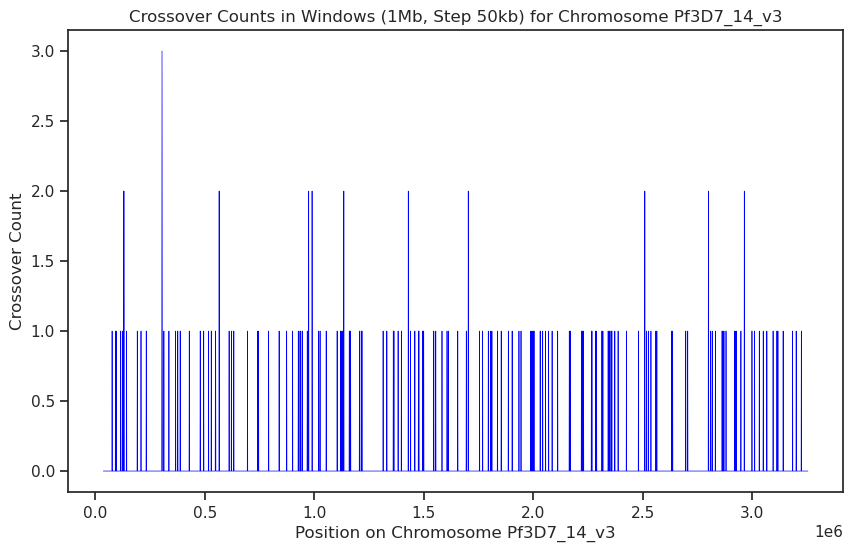

In [27]:

# Apply the windowed_count function
y, windows = allel.windowed_count(tbl_co_chr14_pos, size=100000, start=1, stop=3291936, step=50000, windows= windows_store['Pf3D7_14_v3'])
print("No. of windows",len(y))
# Calculate the center of the windows for plotting
x = windows.mean(axis=1)

# Create the plot
plt.figure(figsize=(10, 6))
sns.despine()
plt.plot(x, y, lw=0.5, color='blue')
plt.xlabel('Position on Chromosome Pf3D7_14_v3')
plt.ylabel('Crossover Count')
plt.title('Crossover Counts in Windows (1Mb, Step 50kb) for Chromosome Pf3D7_14_v3')
#plt.title('Crossover Counts in Windows (1kb, Step 500bp) for Chromosome Pf3D7_14_v3')
plt.show()

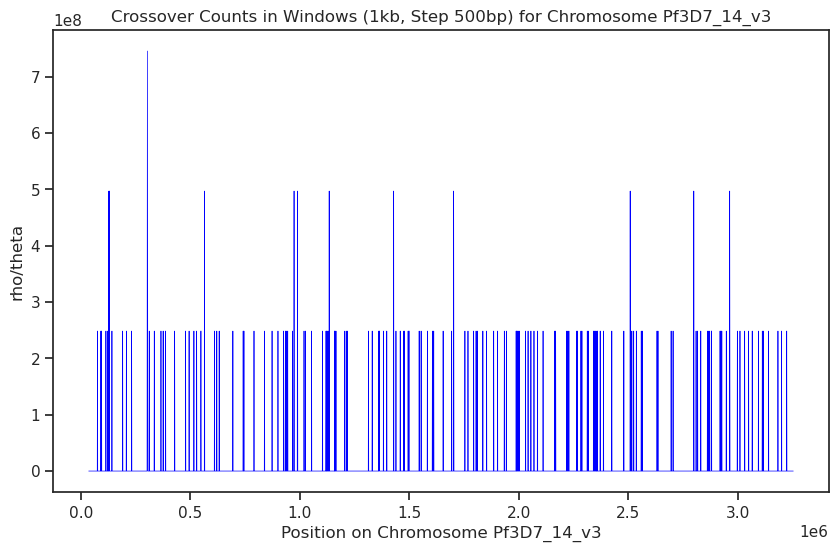

In [35]:
m=4.025e-9  


# Create the plot
plt.figure(figsize=(10, 6))
sns.despine()
plt.plot(x, y/m, lw=0.5, color='blue')
plt.xlabel('Position on Chromosome Pf3D7_14_v3')
plt.ylabel('rho/theta')
#plt.title('Crossover Counts in Windows (1Mb, Step 50kb) for Chromosome Pf3D7_14_v3')
plt.title('Crossover Counts in Windows (1kb, Step 500bp) for Chromosome Pf3D7_14_v3')
plt.show()

In [37]:
len(assessibility_mask.get('Pf3D7_14_v3'))
#chrom_length_for_mask

3291936

In [40]:
len(windows_store['Pf3D7_14_v3'])

642

In [29]:
regions='/home/usriniva/Desktop/masters/plasmodium/find_regions_recomb/regions.txt'
regions= pd.read_csv(regions, sep='\t', names=['region_chrom', 'region_start', 'region_stop', 'region_type'])
regions

,region_chrom,region_start,region_stop,region_type
0,Pf3D7_01_v3,1,27336,SubtelomericRepeat
1,Pf3D7_01_v3,27337,92900,SubtelomericHypervariable
2,Pf3D7_01_v3,92901,457931,Core
3,Pf3D7_01_v3,457932,460311,Centromere
4,Pf3D7_01_v3,460312,575900,Core
...,...,...,...,...
105,Pf3D7_14_v3,35775,1071523,Core
106,Pf3D7_14_v3,1071524,1075089,Centromere
107,Pf3D7_14_v3,1075090,3255710,Core
108,Pf3D7_14_v3,3255711,3291511,SubtelomericHypervariable


In [30]:

# Load genotypes
gt = allel.HaplotypeArray(callset_full['All_chr/calldata/GT'][:,:,0])
genotypes = allel.HaplotypeChunkedArray(gt)

# Initialize dictionaries to store chromosome-specific data
chrom_variants = {}
chrom_pos = {}
chrom_gt = {}

# Loop over chromosomes and subset variants
for chrom in chrom_uniq:
    # Create a boolean mask for the current chromosome
    mask_chrom = variants_full['CHROM'] == chrom
    
    # Use compress to subset the variants for the current chromosome
    chrom_variants[chrom] = variants_full.compress(mask_chrom)
    
    # Extract the positions for the current chromosome from the filtered variants
    chrom_pos[chrom] = np.unique(chrom_variants[chrom]['POS'])
    
    # Subset genotypes for the current chromosome
    chrom_gt[chrom] = genotypes.compress(mask_chrom)

# Define window and step sizes
window_size = 100000
step_size = 5000

# Define subpopulations based on 'subpops' column in the merged DataFrame
subpops = {
    'all': list(range(len(merged))),  # All individuals in the merged dataset
    'MaeSot_Thailand': merged[merged['subpops'] == "MaeSot_Thailand"].index.tolist(),
    'PurPai_Cambodia': merged[merged['subpops'] == "PurPai_Cambodia"].index.tolist(),
    'BinhPhuoc_Long_Vietnam': merged[merged['subpops'] == "BinhPhuoc_Long_Vietnam"].index.tolist()
}


# Function to get positions and genotypes for a chromosome
def get_chrom_data(chrom):
    pos = allel.SortedIndex(chrom_pos[chrom])
    gt = chrom_gt[chrom]
    genotypes = allel.HaplotypeChunkedArray(gt)
    return pos, genotypes

# Function to get annotations for a chromosome
def get_annotations(chrom):
    return chrom_variants[chrom]['ANN_Annotation']

# Function to get allele counts for subpopulations
def get_ac_subpops(chrom, genotypes):
    return genotypes.count_alleles_subpops(subpops=subpops, max_allele=2)

# Function to get masks for different variant types
def get_masks(an):
    # Define variant categories broadly considered as neutrally evolving
    synonymous_variants = [
        'synonymous_variant',
        'splice_region_variant&synonymous_variant',
        #'stop_retained_variant',
        '5_prime_UTR_variant',
        '3_prime_UTR_variant',
        'intron_variant',
        #'intergenic_region',
        'non_coding_transcript_variant',
        #'intragenic_variant',
       # '5_prime_UTR_premature_start_codon_gain_variant'
    ]
    
    missense_mask = np.isin(an, ['missense_variant', 'missense_variant&splice_region_variant'])
    syn_mask = np.isin(an, synonymous_variants)
    intr_mask = np.isin(an, ['intergenic_region'])  # This can be kept as is or modified as needed
    
    return missense_mask, syn_mask, intr_mask


# Function to calculate statistics for a variant type and subpopulation
def calculate_stats(variants, ac_subpops,windows_set):
    nd_win_1, windows, _, _ = allel.windowed_diversity(
        variants, ac_subpops['MaeSot_Thailand'], step=step_size, size=window_size)
    nd_win_2, _, _, _ = allel.windowed_diversity(
        variants, ac_subpops['PurPai_Cambodia'], step=step_size, size=window_size)
    nd_win_3, _, _, _ = allel.windowed_diversity(
        variants, ac_subpops['BinhPhuoc_Long_Vietnam'], step=step_size, size=window_size)

    S1, _, _ = allel.windowed_statistic(variants, ac_subpops['MaeSot_Thailand'].is_segregating()[:],
                                        statistic=np.count_nonzero, step=step_size, size=window_size, fill=0)
    S2, _, _ = allel.windowed_statistic(variants, ac_subpops['PurPai_Cambodia'].is_segregating()[:],
                                        statistic=np.count_nonzero, step=step_size, size=window_size, fill=0)
    S3, _, _ = allel.windowed_statistic(variants, ac_subpops['BinhPhuoc_Long_Vietnam'].is_segregating()[:],
                                        statistic=np.count_nonzero, step=step_size, size=window_size, fill=0)
    stop = chrom_len
    
    wt_1, _, _, _ = allel.windowed_watterson_theta(
        variants, ac_subpops['MaeSot_Thailand'], step=step_size, size=window_size,start =1, stop= stop,windows=windows_set)
    wt_2, _, _, _ = allel.windowed_watterson_theta(
        variants, ac_subpops['PurPai_Cambodia'], step=step_size, size=window_size,start =1, stop= stop,windows=windows_set)
    wt_3, _, _, _ = allel.windowed_watterson_theta(
        variants, ac_subpops['BinhPhuoc_Long_Vietnam'], step=step_size, size=window_size,start =1, stop= stop,windows=windows_set)

    d1, _, _ = allel.windowed_tajima_d(
        variants, ac_subpops['MaeSot_Thailand'], step=step_size, size=window_size)
    d2, _, _ = allel.windowed_tajima_d(
        variants, ac_subpops['PurPai_Cambodia'], step=step_size, size=window_size)
    d3, _, _ = allel.windowed_tajima_d(
        variants, ac_subpops['BinhPhuoc_Long_Vietnam'], step=step_size, size=window_size)

    return windows, (nd_win_1, nd_win_2, nd_win_3), (S1, S2, S3), (wt_1, wt_2, wt_3), (d1, d2, d3)

# Function to convert genomic positions to kilobases and calculate midpoints
def get_midpoints(windows):
    midpoint_positions = (windows[:, 0] + windows[:, 1]) / 2
    return midpoint_positions / 1000  # Assuming positions in base pairs


In [31]:
# Calculate total length of each chromosome
chrom_lengths = chrom_regions.groupby('chrom')['end'].max()

# Convert chrom_lengths (Series) to DataFrame
chrom_lengths = pd.DataFrame(chrom_lengths)

# Display total chromosome lengths
print(chrom_lengths)

                 end
chrom               
Pf3D7_01_v3   640851
Pf3D7_02_v3   947102
Pf3D7_03_v3  1067971
Pf3D7_04_v3  1200490
Pf3D7_05_v3  1343577
Pf3D7_06_v3  1418242
Pf3D7_07_v3  1445207
Pf3D7_08_v3  1472805
Pf3D7_09_v3  1541735
Pf3D7_10_v3  1687656
Pf3D7_11_v3  2038340
Pf3D7_12_v3  2271494
Pf3D7_13_v3  2925236
Pf3D7_14_v3  3291936


In [32]:
windows_store

{'Pf3D7_01_v3': array([[ 92901,  93900],
        [ 93401,  94400],
        [ 93901,  94900],
        ...,
        [573901, 574900],
        [574401, 575400],
        [574901, 575900]], shape=(965, 2)),
 'Pf3D7_02_v3': array([[105801, 106800],
        [106301, 107300],
        [106801, 107800],
        ...,
        [860301, 861300],
        [860801, 861800],
        [861301, 862300]], shape=(1512, 2)),
 'Pf3D7_03_v3': array([[  70631,   71630],
        [  71131,   72130],
        [  71631,   72630],
        ...,
        [1000631, 1001630],
        [1001131, 1002130],
        [1001631, 1002630]], shape=(1863, 2)),
 'Pf3D7_04_v3': array([[  91421,   92420],
        [  91921,   92920],
        [  92421,   93420],
        ...,
        [1141571, 1142570],
        [1142071, 1143070],
        [1142571, 1143570]], shape=(1869, 2)),
 'Pf3D7_05_v3': array([[  37901,   38900],
        [  38401,   39400],
        [  38901,   39900],
        ...,
        [1318901, 1319900],
        [1319401, 1320400

In [33]:
all_midpoints_syn = []
all_nd1_syn = []
all_nd2_syn = []
all_nd3_syn = []
all_wt1_syn = []
all_wt2_syn = []
all_wt3_syn = []
all_s1_syn = []
all_s2_syn = []
all_s3_syn = []
all_d1_syn = []
all_d2_syn = []
all_d3_syn = []
chrom_boundaries=[]

# Initialize the cumulative end position
cumulative_end_position = 0

# Loop over chromosomes
for chrom, chrom_len in chrom_lengths.itertuples():
    pos, genotypes = get_chrom_data(chrom)
    
    an = get_annotations(chrom)
    ac_subpops = get_ac_subpops(chrom, genotypes)
    
    missense_mask, syn_mask, intr_mask = get_masks(an)

    # Check and process synonymous variants
    synonymous_variants = pos.compress(syn_mask)
    if synonymous_variants.size > 0:
        ac_subpops_synonymous = ac_subpops.compress(syn_mask)
        windows_set= windows_store[chrom]
        windows_syn, nd_syn, S_syn, wt_syn, d_syn = calculate_stats(synonymous_variants, ac_subpops_synonymous,windows_set)
        
        # Concatenate data for synonymous
        #all_midpoints_syn.append(midpoint_positions_syn)
        all_nd1_syn.append(nd_syn[0])
        all_nd2_syn.append(nd_syn[1])
        all_nd3_syn.append(nd_syn[2])
        all_wt1_syn.append(wt_syn[0])
        all_wt2_syn.append(wt_syn[1])
        all_wt3_syn.append(wt_syn[2])
        all_s1_syn.append(S_syn[0])
        all_s2_syn.append(S_syn[1])
        all_s3_syn.append(S_syn[2])
        all_d1_syn.append(d_syn[0])
        all_d2_syn.append(d_syn[1])
        all_d3_syn.append(d_syn[2])

    


In [96]:
len(all_wt1_syn[13])

63

In [ ]:
# Function to compute rolling average for a given window size
def compute_rolling_average(values, window_size=10):
    # Use pandas rolling function to compute the rolling average with the specified window size
    rolling_avg = pd.Series(values).rolling(window=window_size, min_periods=1).mean()
    return rolling_avg
# Function to plot synonymous nucleotide diversity
def plot_synonymous_nucleotide_diversity(midpoints, nd_win, chrom_boundaries, title_suffix, color, rolling_window=10):
    # Compute the rolling average for the given nucleotide diversity values
    smoothed_nd_win = compute_rolling_average(nd_win, window_size=rolling_window)
    
    fig, ax = plt.subplots(figsize=(18, 6))  # Create a new figure for each plot

    # Set the plot header
    ax.set_title(f"Synonymous Nucleotide Diversity - {title_suffix}", fontsize=20, color='black', y=1.1)

    # Font size settings
    label_fontsize = 18  # Font size for axis labels
    tick_fontsize = 16   # Font size for tick labels

    # Plot the smoothed statistic values
    ax.plot(midpoints, smoothed_nd_win, lw=2, color=color, label="Smoothed Synonymous Nucleotide Diversity")
    ax.axhline(y=0.000125, color='red', linestyle=':', label="nt= 0.000125")
    # Set axis labels
    ax.set_xlabel('Position (kbp)', color='black', fontsize=label_fontsize)
    ax.set_ylabel('Synonymous Nucleotide Diversity', color='black', fontsize=label_fontsize)

    # Customize y-axis limits as needed
    ax.set_ylim(0, 0.002)

    # Grid and tick settings
    ax.grid(True)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

    # Add vertical lines for chromosome boundaries
    for boundary in chrom_boundaries[:-1]:
        ax.axvline(x=boundary, color='gray', linestyle='--')

    # Add chromosome labels
    chrom_nos = [f"{i+1:02}" for i in range(len(chrom_boundaries))]
    chrom_midpoints = [(0 if i == 0 else chrom_boundaries[i-1] + (chrom_boundaries[i] - chrom_boundaries[i-1]) / 2) for i in range(len(chrom_boundaries))]
    for chrom, midpoint in zip(chrom_nos, chrom_midpoints):
        ax.text(midpoint, ax.get_ylim()[1], f'{chrom}', horizontalalignment='center', verticalalignment='bottom', fontsize=16)

    # Adjust the layout to make room for the title
    plt.tight_layout(rect=[0, 0, 1, 0.95])

# Example plot for synonymous nucleotide diversity using your calculated data
plot_synonymous_nucleotide_diversity(all_midpoints_syn, all_nd1_syn, chrom_boundaries, 'MaeSot_Thailand', 'tomato', rolling_window=10)
plot_synonymous_nucleotide_diversity(all_midpoints_syn, all_nd2_syn, chrom_boundaries, 'PurPai_Cambodia', 'darkorange', rolling_window=10)
plot_synonymous_nucleotide_diversity(all_midpoints_syn, all_nd3_syn, chrom_boundaries, 'BinhPhuoc_Long_Vietnam', 'green', rolling_window=10)


In [75]:
len(y)

63

In [97]:
pb,bases_window =allel.per_base(y, windows, is_accessible=None, fill=np.nan)

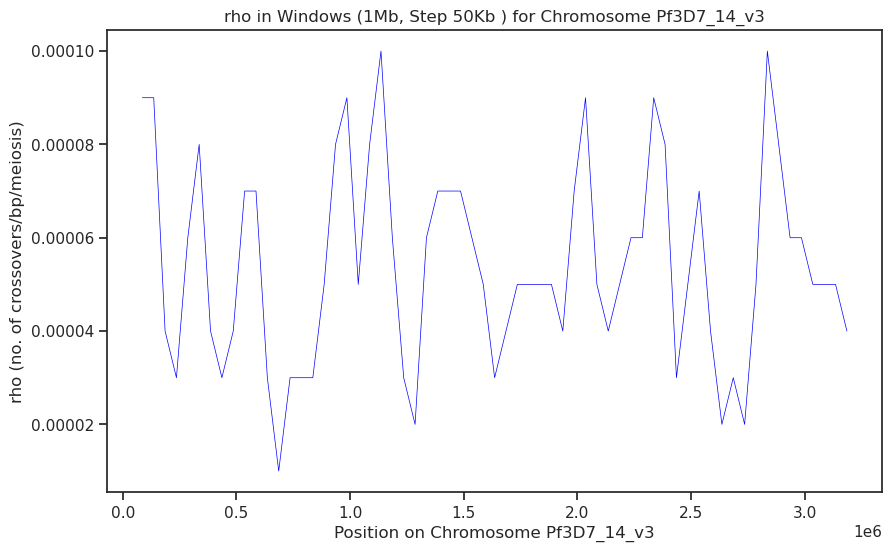

In [99]:

# Create the plot
plt.figure(figsize=(10, 6))
sns.despine()
plt.plot(x, pb, lw=0.5, color='blue')
plt.xlabel('Position on Chromosome Pf3D7_14_v3')
plt.ylabel('rho (no. of crossovers/bp/meiosis)')
#plt.title('rho in Windows (1kb, Step 500bp ) for Chromosome Pf3D7_14_v3')
plt.title('rho in Windows (1Mb, Step 50Kb ) for Chromosome Pf3D7_14_v3')
plt.show()

In [255]:
len(pb)

6438

/tmp/ipykernel_477032/1301625454.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.plot(x, pb/all_wt1_syn[13], lw=0.8, color='blue')
/tmp/ipykernel_477032/1301625454.py:4: RuntimeWarning: invalid value encountered in divide
  plt.plot(x, pb/all_wt1_syn[13], lw=0.8, color='blue')


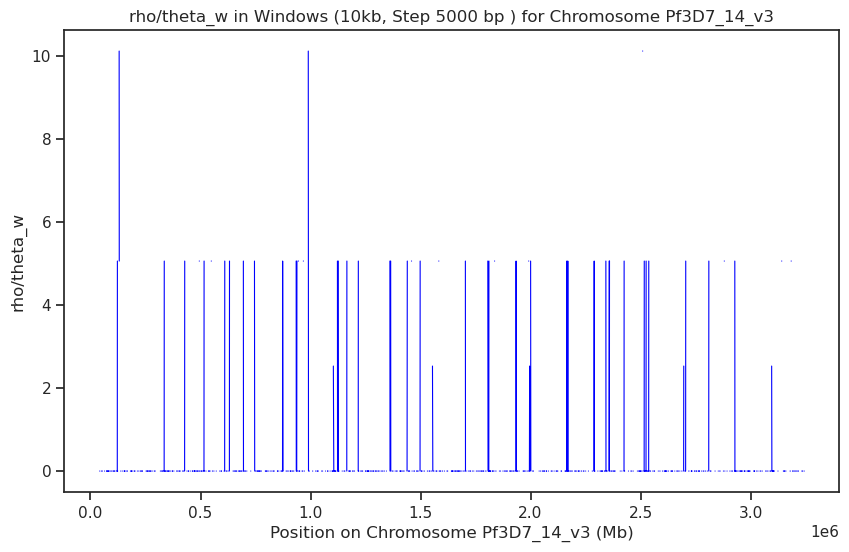

In [83]:

# Create the plot
plt.figure(figsize=(10, 6))
sns.despine()
plt.plot(x, pb/all_wt1_syn[13], lw=0.8, color='blue')
plt.xlabel('Position on Chromosome Pf3D7_14_v3 (Mb)')
plt.ylabel('rho/theta_w')
plt.title('rho/theta_w in Windows (10kb, Step 5000 bp ) for Chromosome Pf3D7_14_v3')
plt.show()

In [ ]:

print(pb)  # Now it will print the full content


[0. 0. 0. ... 0. 0. 0.]


In [252]:

print(all_wt1_syn)

[array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.00019762, 0.00039524, 0.00019762, 0.00019762,
       0.00039524, 0.00019762, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.00019762, 0.00019762, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.00019762, 0.00019762, 0.00019762, 0.00019762, 0.        ,
       0.        , 0.        , 0.        , 0.00039524, 0.00039524,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.00019762, 0.00019762,
       0.00019762, 0.00019762, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.    

In [ ]:
pb,bases_window =allel.per_base(y, windows, is_accessible=None, fill=np.nan)
# Create the plot
plt.figure(figsize=(10, 6))
sns.despine()
plt.plot(x, pb/all_wt1_syn[13], lw=0.5, color='blue')
plt.xlabel('Position on Chromosome Pf3D7_14_v3')
plt.ylabel('Crossover Count')
plt.title('Crossover Counts in Windows (10kb, Step 5kb) for Chromosome Pf3D7_14_v3')
plt.show()